# Frost Days in the Pyrenees: 1980 vs 2023 Comparison

This notebook demonstrates how to compare frost days between two distinct years (1980 and 2023) using **ERA5 reanalysis data** in its native GRIB format. Using the `earthkit-climate` package, we will compute the **Frost Days (FD)** index for the **Aragonese Pyrenees** and visualize the difference in frost occurrences.

> [!NOTE]
> The data shown in this repository is for **demonstration purposes only**. To obtain the full datasets for professional analysis, please use the official channels.

## Prerequisites & Data Access

To run this notebook, you must have an account on the [Copernicus Climate Data Store (CDS)](https://cds.climate.copernicus.eu/).

### CDS API Configuration
Because `earthkit` retrieves ERA5 data via the `cdsapi`, you need to configure your API access. Instead of manual local configuration, we recommend following the **official guide** to ensure your setup is always up to date:

* **[Official CDS API How-to Guide](https://cds.climate.copernicus.eu/how-to-api)**

### What is the Frost Days (FD) Index?
The Frost Days index is defined as the number of days in a year where the daily minimum temperature ($T_{min}$) falls below 0°C. It is a key indicator for agriculture, hydrology, and biodiversity in high-mountain ecosystems.


## 1. Setup and Study Area

First, we import the necessary libraries and define our coordinates for the Aragonese Pyrenees (Bounding Box).

In [8]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.transforms as ekt
import numpy as np

from earthkit.climate.indicators import temperature

## 2. Data Acquisition (ERA5)

We use the Copernicus Climate Data Store (CDS) API to download hourly 2m temperature data. You can find the official dataset entry here:

* **[ERA5 single levels reanalysis](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview)**

We download data for the peak frost months (January-March and October-December) for both 1980 and 2023 for our study area.

In [9]:
# 1. Define the study area [North, West, South, East]
# Coordinates for the Aragonese Pyrenees
PYRENEES_AREA = [43, -1, 42, 0.8]

print("Requesting data from CDS... (this might take a few minutes)")

# 2. Retrieve and open 1980 data (The Baseline)
data_1980 = ekd.from_source(
    "cds",
    "reanalysis-era5-single-levels",
    variable="2m_temperature",
    product_type="reanalysis",
    year="1980",
    month=[f"{i:02d}" for i in range(1, 13)],
    day=[f"{i:02d}" for i in range(1, 32)],
    time=[f"{i:02d}:00" for i in range(24)],
    area=PYRENEES_AREA,
    format="grib",
)

# 4. Retrieve and open 2023 data (The Comparison)
data_2023 = ekd.from_source(
    "cds",
    "reanalysis-era5-single-levels",
    variable="2m_temperature",
    product_type="reanalysis",
    year="2023",
    month=[f"{i:02d}" for i in range(1, 13)],
    day=[f"{i:02d}" for i in range(1, 32)],
    time=[f"{i:02d}:00" for i in range(24)],
    area=PYRENEES_AREA,
    format="grib",
)

print("Data successfully loaded into earthkit objects!")

Requesting data from CDS... (this might take a few minutes)
Data successfully loaded into earthkit objects!


## 3. Processing with Earthkit & Xarray

We now process the hourly temperature data in Kelvin to obtain the annual count of Frost Days.

In [10]:
# 1. Load data and rename variables
# '2t' is the ERA5 shorthand for 2m temperature
ds_80 = data_1980.to_xarray(time_dim_mode="forecast").rename({"2t": "tas", "forecast_reference_time": "time"})
ds_23 = data_2023.to_xarray(time_dim_mode="forecast").rename({"2t": "tas", "forecast_reference_time": "time"})

# 2. Set essential CF-compliant attributes
# We keep the data in Kelvin (K) as it's the CF standard
for ds in [ds_80, ds_23]:
    ds["tas"].attrs.update({
        "standard_name": "air_temperature",
        "units": "K",
        "cell_methods": "time: point",  # Instantaneous hourly values
    })

# 3. Calculate Daily Minimum Temperature (Tmin)
# Resampling often "cleans" attributes, so we re-apply them to the result
tmin_80 = ekt.temporal.daily_reduce(ds_80["tas"], how="min")
tmin_23 = ekt.temporal.daily_reduce(ds_23["tas"], how="min")

for tmin in [tmin_80, tmin_23]:
    tmin.attrs["units"] = "K"
    tmin.attrs["standard_name"] = "air_temperature"
    tmin.attrs["cell_methods"] = "time: minimum"  # Now it represents the daily min

# 4. Compute Frost Days Index
# frost_days automatically detects 'K' and uses 273.15 as the freezing threshold
fd_80 = temperature.frost_days(tmin_80).squeeze()
fd_23 = temperature.frost_days(tmin_23).squeeze()

# 5. Calculate the difference (loss of frost days)
# A negative value indicates fewer frost days in 2023 compared to 1980
diff_fd = fd_23 - fd_80

## 4. Visualizing the "Cold Retreat"

We'll plot the difference between the two periods to visualize where the decrease in Frost Days is most significant.

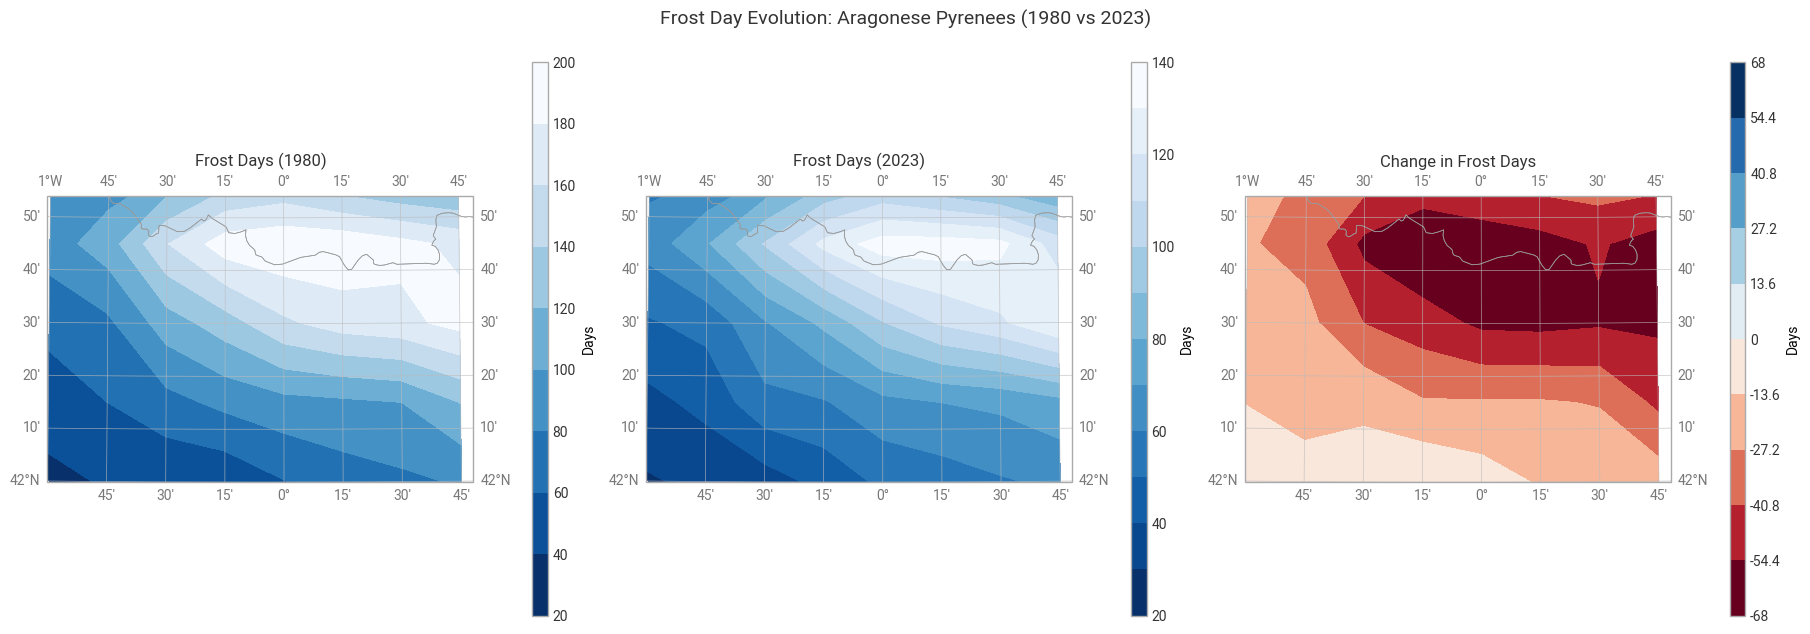

In [11]:
# Define the Aragonese Pyrenees bounding box [min_lon, max_lon, min_lat, max_lat]
# Adjust these slightly if your specific dataset has different borders
ARAGON_EXTENT = [-1.0, 0.8, 42.0, 42.9]

plot_matrix = [
    [
        ("Frost Days (1980)", fd_80, "Blues_r"),
        ("Frost Days (2023)", fd_23, "Blues_r"),
        ("Change in Frost Days", diff_fd, "RdBu"),  # _r flips it so red = decrease/warming
    ]
]

figure = ekp.Figure(rows=1, columns=3, size=(18, 7))

for row_idx, row_plots in enumerate(plot_matrix):
    for col_idx, (name, data, cmap) in enumerate(row_plots):
        # Create map and immediately set the spatial focus
        map_plot = figure.add_map(row=row_idx, column=col_idx, domain=ARAGON_EXTENT)

        # Validate data within the domain
        valid_data = data.values[~np.isnan(data.values)]

        if valid_data.size == 0:
            map_plot.title(f"{name} (No data in domain)")
            continue

        # Logic to center the anomaly colorbar at 0
        if "Change" in name or "Anomaly" in name:
            # Find the maximum absolute deviation from zero
            max_val = np.nanmax(np.abs(valid_data))
            # Create symmetric levels (e.g., from -40 to +40)
            style = ekp.styles.Style(colors=cmap, levels=np.linspace(-max_val, max_val, 11))
        elif np.all(valid_data == valid_data[0]):
            style = ekp.styles.Style(colors=cmap, levels=[valid_data[0] - 1, valid_data[0] + 1])
        else:
            style = ekp.styles.Style(colors=cmap)

        # Plotting & Layers
        map_plot.quickplot(data, style=style)

        # Adding high-resolution features for a small domain
        map_plot.coastlines(resolution="10m", color="black", linewidth=1)
        map_plot.borders(resolution="10m", linestyle="-")  # Helpful for France/Spain border

        # Gridlines with labels restricted to the Pyrenees box
        map_plot.gridlines(draw_labels=True, dms=True)

        map_plot.title(name, fontsize=12)
        map_plot.legend(location="right", label="Days")

# Add a super-title for the entire figure
figure.title("Frost Day Evolution: Aragonese Pyrenees (1980 vs 2023)")
figure.show()